### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

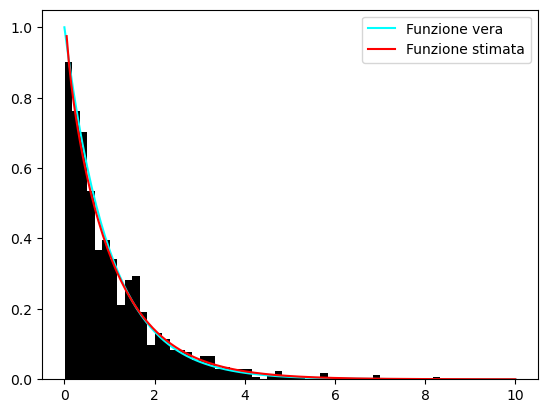

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
ris = sp.stats.gamma(1)
samples = ris.rvs(1000)
x=np.linspace(0,10,200)
y = sp.stats.gamma(1).pdf(x)

plt.hist(samples,bins=50, density=True,color="black")
plt.plot(x,y,label= "Funzione vera",color="cyan")

shape,loc,scale = sp.stats.gamma.fit(samples) 
funzStimata=sp.stats.gamma(shape,loc=0,scale=scale).pdf(x)  #loc=0 perché f(0)=1 (cosi stima bene e non parte da 0)
plt.plot(x,funzStimata,label="Funzione stimata",color="red")
plt.legend()
plt.show()




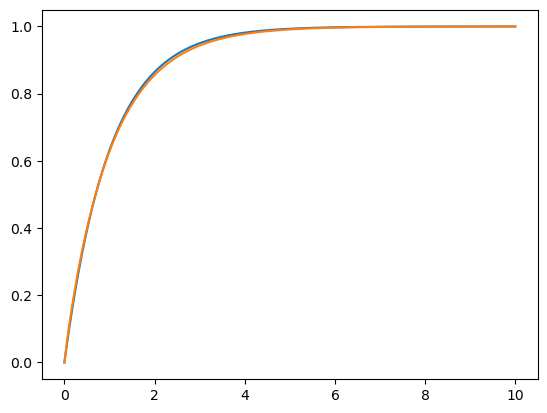

In [65]:
plt.plot(x,sp.stats.gamma(1).cdf(x))
plt.plot(x,sp.stats.gamma(shape,loc=loc,scale=scale).cdf(x))


### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

MAE 1 Grado: 1.7369055356949374
MAE 2 Grado: 1.5804121709001493
MAE 3 Grado: 1.4419243478403496
RMSE 1 Grado: 2.0493088794342142
RMSE 2 Grado: 1.8553554555642187
RMSE 3 Grado: 1.8157460951326243


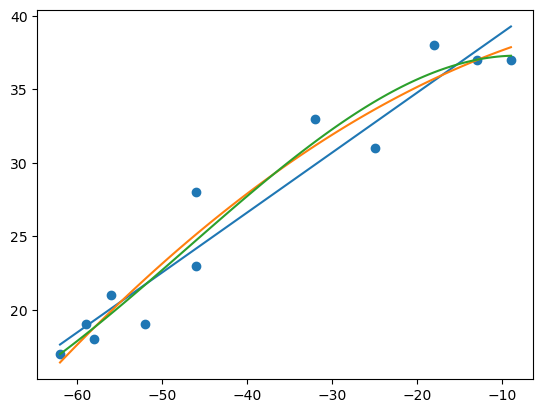

In [17]:

import numpy as np

def mae(y, y_pred):
    return np.mean(np.abs(y - y_pred))

def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred)**2))




temp_max = np.array([17,   19,  21,  28,  33,  38, 37,  37,  31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt

x = np.linspace(temp_min.min(),temp_min.max(),100)

coeffs1 = np.polyfit(temp_min,temp_max,1)
p1 = np.poly1d(coeffs1)
y_pred1= p1(x)

coeffs2 = np.polyfit(temp_min,temp_max,2)
p2 = np.poly1d(coeffs2)
y_pred2= p2(x)

coeffs3 = np.polyfit(temp_min,temp_max,3)
p3 = np.poly1d(coeffs3)
y_pred3= p3(x)


mae1 = mae(temp_max, p1(temp_min))
rmse1 = rmse(temp_max, p1(temp_min))

mae2 = mae(temp_max, p2(temp_min))
rmse2 = rmse(temp_max, p2(temp_min))

mae3 = mae(temp_max, p3(temp_min))
rmse3 = rmse(temp_max, p3(temp_min))


print("MAE 1 Grado:",mae1)
print("MAE 2 Grado:",mae2)
print("MAE 3 Grado:",mae3)
print("RMSE 1 Grado:",rmse1)
print("RMSE 2 Grado:",rmse2)
print("RMSE 3 Grado:",rmse3)

plt.scatter(temp_min,temp_max)


plt.plot(x,y_pred1,label="Grado 1")
plt.plot(x,y_pred2,label="Grado 2")
plt.plot(x,y_pred3,label="Grado 3")


### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

MAE: 2.1738231673880293
RMSE: 2.700654841526459


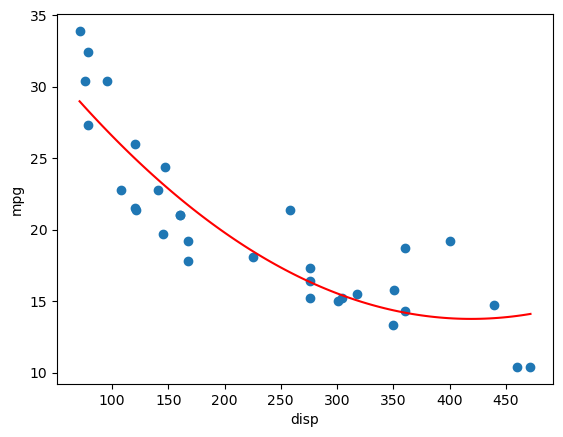

In [ ]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df

x = df['disp'].values
y = df['mpg'].values

def mae(y, y_pred):
    return np.mean(np.abs(y - y_pred))

def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred)**2))

x_plot = np.linspace(x.min(), x.max(), 100)

coeffs = np.polyfit(x, y, 2)
# di grado 2 dato che,anche a occhio, una retta non stima bene l'andamento.
# potrei anche aumentare il grado ma ciò non renderebbe il modello migliore
p = np.poly1d(coeffs)
y_plot = p(x_plot)
y_pred = p(x)

print("MAE:", mae(y, y_pred))
print("RMSE:", rmse(y, y_pred))

plt.scatter(x, y)
plt.plot(x_plot, y_plot, color='red')
plt.xlabel("disp")
plt.ylabel("mpg")
plt.show()